In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)

In [2]:
data_path = Path("cleaned_residential_single_family_preprocessed.csv")

if not data_path.exists():
    data_path = Path("residential_single_family_eda.csv")

df = pd.read_csv(data_path)

print("Loaded:", data_path)
print("Shape:", df.shape)

df.head()

Loaded: cleaned_residential_single_family_preprocessed.csv
Shape: (399155, 11)


,CloseDate,CloseMonth,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize,LivingArea_missing,Bedrooms_missing,Bathrooms_missing,LotSize_missing
0,2022-01-01,2022-01,535000.0,2061.0,4.0,2.0,12232.0,0,0,0,0
1,2022-01-01,2022-01,560000.0,1546.0,3.0,2.0,27225.0,0,0,0,0
2,2022-01-02,2022-01,3300000.0,3085.0,3.0,3.0,42237.0,0,0,0,0
3,2022-01-03,2022-01,1700000.0,2916.0,4.0,3.0,5654.0,0,0,0,0
4,2022-01-03,2022-01,405000.0,1632.0,3.0,2.0,6151.0,0,0,0,0


In [3]:
df.columns.tolist()

['CloseDate',
 'CloseMonth',
 'ClosePrice',
 'LivingArea',
 'Bedrooms',
 'Bathrooms',
 'LotSize',
 'LivingArea_missing',
 'Bedrooms_missing',
 'Bathrooms_missing',
 'LotSize_missing']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399155 entries, 0 to 399154
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CloseDate           399155 non-null  object 
 1   CloseMonth          399155 non-null  object 
 2   ClosePrice          399155 non-null  float64
 3   LivingArea          398945 non-null  float64
 4   Bedrooms            399155 non-null  float64
 5   Bathrooms           399080 non-null  float64
 6   LotSize             392329 non-null  float64
 7   LivingArea_missing  399155 non-null  int64  
 8   Bedrooms_missing    399155 non-null  int64  
 9   Bathrooms_missing   399155 non-null  int64  
 10  LotSize_missing     399155 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 33.5+ MB


In [5]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")

df["CloseMonth"] = df["CloseDate"].dt.to_period("M")

model_df = df.dropna(subset=["CloseDate", "ClosePrice"]).copy()
model_df = model_df.sort_values("CloseDate").reset_index(drop=True)

print("Date range:", model_df["CloseDate"].min(), "to", model_df["CloseDate"].max())

model_df["CloseMonth"].value_counts().sort_index()

Date range: 2022-01-01 00:00:00 to 2026-05-31 00:00:00


CloseMonth
2022-01     2313
2022-02     1227
2022-03      873
2022-04      408
2022-05      229
2022-06      171
2022-07      100
2022-08       72
2022-09       50
2022-10       38
2022-11       23
2022-12       17
2023-01       12
2023-02       19
2023-03       20
2023-04       80
2023-05     1832
2023-06     8601
2023-07     9888
2023-08    11715
2023-09    10744
2023-10    11033
2023-11     9668
2023-12     9518
2024-01     8322
2024-02     9564
2024-03    11634
2024-04    12745
2024-05    13831
2024-06    12544
2024-07    13378
2024-08    12433
2024-09    10909
2024-10    12347
2024-11    10692
2024-12    10623
2025-01     8144
2025-02     8851
2025-03    10610
2025-04    11880
2025-05    11777
2025-06    11701
2025-07    12114
2025-08    11454
2025-09    11456
2025-10    12029
2025-11     9739
2025-12    10455
2026-01     7490
2026-02     8550
2026-03    11177
2026-04    12031
2026-05    12024
Freq: M, Name: count, dtype: int64

In [6]:
all_months = sorted(model_df["CloseMonth"].dropna().unique())

test_month = all_months[-1]

train_df = model_df[model_df["CloseMonth"] < test_month].copy()
test_df = model_df[model_df["CloseMonth"] == test_month].copy()

print("Test month:", test_month)
print("Train months:", sorted(train_df["CloseMonth"].unique()))
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Test month: 2026-05
Train months: [Period('2022-01', 'M'), Period('2022-02', 'M'), Period('2022-03', 'M'), Period('2022-04', 'M'), Period('2022-05', 'M'), Period('2022-06', 'M'), Period('2022-07', 'M'), Period('2022-08', 'M'), Period('2022-09', 'M'), Period('2022-10', 'M'), Period('2022-11', 'M'), Period('2022-12', 'M'), Period('2023-01', 'M'), Period('2023-02', 'M'), Period('2023-03', 'M'), Period('2023-04', 'M'), Period('2023-05', 'M'), Period('2023-06', 'M'), Period('2023-07', 'M'), Period('2023-08', 'M'), Period('2023-09', 'M'), Period('2023-10', 'M'), Period('2023-11', 'M'), Period('2023-12', 'M'), Period('2024-01', 'M'), Period('2024-02', 'M'), Period('2024-03', 'M'), Period('2024-04', 'M'), Period('2024-05', 'M'), Period('2024-06', 'M'), Period('2024-07', 'M'), Period('2024-08', 'M'), Period('2024-09', 'M'), Period('2024-10', 'M'), Period('2024-11', 'M'), Period('2024-12', 'M'), Period('2025-01', 'M'), Period('2025-02', 'M'), Period('2025-03', 'M'), Period('2025-04', 'M'), Perio

In [7]:
target = "ClosePrice"

base_numeric_features = [
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize"
]

for col in base_numeric_features:
    missing_col = f"{col}_missing"
    
    if missing_col not in model_df.columns:
        model_df[missing_col] = model_df[col].isna().astype(int)
    
    if missing_col not in train_df.columns:
        train_df[missing_col] = train_df[col].isna().astype(int)
    
    if missing_col not in test_df.columns:
        test_df[missing_col] = test_df[col].isna().astype(int)

missing_flag_features = [f"{col}_missing" for col in base_numeric_features]

numeric_features = base_numeric_features + missing_flag_features

numeric_features

['LivingArea',
 'Bedrooms',
 'Bathrooms',
 'LotSize',
 'LivingArea_missing',
 'Bedrooms_missing',
 'Bathrooms_missing',
 'LotSize_missing']

In [8]:
candidate_categorical_features = [
    "City",
    "PostalCode",
    "CountyOrParish"
]

categorical_features = [
    col for col in candidate_categorical_features
    if col in model_df.columns
]

categorical_features

[]

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

transformers = [
    ("num", numeric_transformer, numeric_features)
]

if len(categorical_features) > 0:
    transformers.append(("cat", categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)

all_features = numeric_features + categorical_features

print("Features used:")
print(all_features)

Features used:
['LivingArea', 'Bedrooms', 'Bathrooms', 'LotSize', 'LivingArea_missing', 'Bedrooms_missing', 'Bathrooms_missing', 'LotSize_missing']


In [10]:
X_train = train_df[all_features]
y_train = train_df[target]

X_test = test_df[all_features]
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (387131, 8)
X_test shape: (12024, 8)
y_train shape: (387131,)
y_test shape: (12024,)


In [11]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    mask = y_true != 0
    y_true_nonzero = y_true[mask]
    y_pred_nonzero = y_pred[mask]
    
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true_nonzero, y_pred_nonzero)
    mdape = np.median(
        np.abs((y_true_nonzero - y_pred_nonzero) / y_true_nonzero)
    )
    
    return {
        "R2": r2,
        "MAPE": mape,
        "MdAPE": mdape
    }

In [12]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

linear_metrics = regression_metrics(y_test, linear_preds)

linear_metrics

{'R2': 0.20855190291106307,
 'MAPE': 0.6712496011889557,
 'MdAPE': np.float64(0.44681576386340804)}

In [13]:
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=20,
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

tree_preds = decision_tree_model.predict(X_test)

tree_metrics = regression_metrics(y_test, tree_preds)

tree_metrics

{'R2': 0.1036121599096026,
 'MAPE': 0.5949740192311994,
 'MdAPE': np.float64(0.3650960926097341)}

In [14]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_preds = random_forest_model.predict(X_test)

rf_metrics = regression_metrics(y_test, rf_preds)

rf_metrics

{'R2': -0.16564920376175007,
 'MAPE': 0.5615937484532755,
 'MdAPE': np.float64(0.3066434186934348)}

In [15]:
results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "R2": linear_metrics["R2"],
        "MAPE": linear_metrics["MAPE"],
        "MdAPE": linear_metrics["MdAPE"]
    },
    {
        "Model": "Decision Tree",
        "R2": tree_metrics["R2"],
        "MAPE": tree_metrics["MAPE"],
        "MdAPE": tree_metrics["MdAPE"]
    },
    {
        "Model": "Random Forest",
        "R2": rf_metrics["R2"],
        "MAPE": rf_metrics["MAPE"],
        "MdAPE": rf_metrics["MdAPE"]
    }
])

results["MAPE_%"] = results["MAPE"] * 100
results["MdAPE_%"] = results["MdAPE"] * 100

results.sort_values("R2", ascending=False)

,Model,R2,MAPE,MdAPE,MAPE_%,MdAPE_%
0,Linear Regression,0.208552,0.671250,0.446816,67.124960,44.681576
1,Decision Tree,0.103612,0.594974,0.365096,59.497402,36.509609
2,Random Forest,-0.165649,0.561594,0.306643,56.159375,30.664342


In [16]:
results.to_csv("week5_model_comparison_results.csv", index=False)

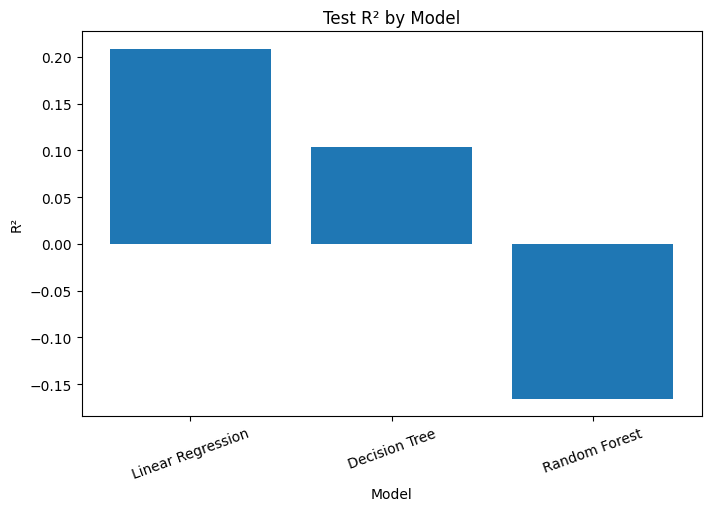

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["R2"])
plt.title("Test R² by Model")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.show()

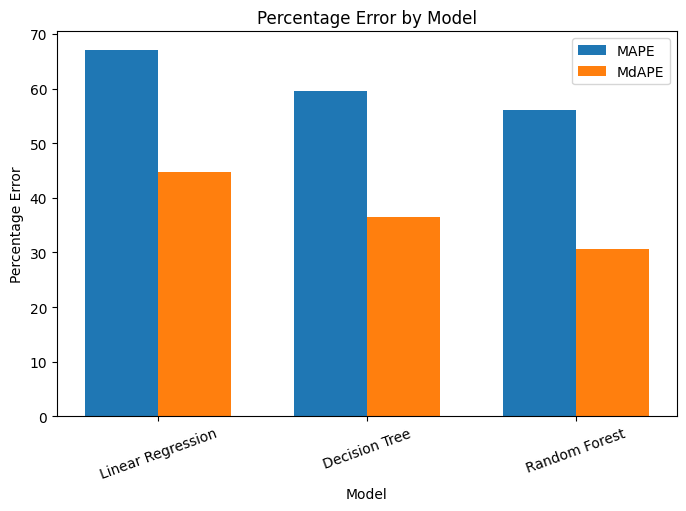

In [18]:
plt.figure(figsize=(8, 5))

x = np.arange(len(results["Model"]))
width = 0.35

plt.bar(x - width / 2, results["MAPE_%"], width, label="MAPE")
plt.bar(x + width / 2, results["MdAPE_%"], width, label="MdAPE")

plt.title("Percentage Error by Model")
plt.xlabel("Model")
plt.ylabel("Percentage Error")
plt.xticks(x, results["Model"], rotation=20)
plt.legend()
plt.show()